In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plot 
import darts 
import darts.utils.timeseries_generation as tg 
from darts.dataprocessing.transformers import Scaler 
from darts import TimeSeries
from darts.utils.missing_values import fill_missing_values
from darts.datasets import AirPassengersDataset
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.models import RNNModel , NBEATSModel , TFTModel , TCNModel
from darts.metrics import mae , mape 
from darts.utils.likelihood_models import GaussianLikelihood

In [4]:
airpass_ts = AirPassengersDataset().load()
days = pd.Series(
    airpass_ts.time_index.days_in_month
    ,
    index = airpass_ts.time_index
)
print(airpass_ts.shape)
airpass_ts = airpass_ts/TimeSeries.from_series(days)
print(airpass_ts.shape)

(144, 1, 1)
(144, 1, 1)


In [5]:
airpass_train,airpass_validation = airpass_ts.split_after(pd.Timestamp("19571201"))
scaler = Scaler()
airpass_train_scaled = scaler.fit_transform(airpass_train)
airpass_scaled = scaler.transform(airpass_ts)
airpass_validation_scaled = scaler.transform(airpass_validation)

In [6]:
cov = datetime_attribute_timeseries(airpass_ts,attribute="year",one_hot=False)
cov = cov.stack(datetime_attribute_timeseries(airpass_ts,attribute="month",one_hot=False))
cov = cov.stack(
    TimeSeries.from_times_and_values(
        times = airpass_ts.time_index
        ,
        values = np.arange(len(airpass_ts))
    )
)
cov = cov.astype(np.float32)
cov_train,cov_validation = cov.split_after(pd.Timestamp("19571201"))
cov_scaler = Scaler()
cov_train_scaled = cov_scaler.fit_transform(cov_train)
cov_validation_scaled = cov_scaler.transform(cov_validation)
cov_scaled = cov_scaler.transform(cov)

In [7]:
rnn_model = RNNModel(
    input_chunk_length=20
    ,
    training_length=50
    ,
    hidden_dim=30
    ,
    n_rnn_layers=4
    ,
    model="LSTM"
    ,
    n_epochs=100
    ,
    likelihood = GaussianLikelihood()
    ,
    dropout=0.2
    ,
    kwargs=dict(learning_rate=0.1)
)

In [8]:
rnn_model.fit(series=airpass_train_scaled)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 26.3 K | train
6 | V               | Linear           | 62     | train
-------------------------------------------------------------
26.3 K    Trainable params
0         Non-trainable params
26.3 K    Total params
0.105     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
c:\Users\KETABI\anaconda3\envs\ml-tools\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' arg

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


RNNModel(model=LSTM, hidden_dim=30, n_rnn_layers=4, dropout=0.2, training_length=50, input_chunk_length=20, n_epochs=100, likelihood=GaussianLikelihood(prior_mu=None, prior_sigma=None, beta_nll=0.0, prior_strength=1.0), kwargs={'learning_rate': 0.1})

In [9]:
def model_evaluation(model, n, actual_data, val_data):
  num_samples = 200
  quantile01 , quantile02, quantile03, quantile04 = 0.01, 0.1, 0.9, 0.99
  predicted_data = model.predict(n=n, num_samples=num_samples)
  predicted_data = scaler.inverse_transform(predicted_data)
  actual_data = scaler.inverse_transform(actual_data)
  val_data = scaler.inverse_transform(val_data)
  plot.figure(figsize=(10, 6))
  actual_data[:predicted_data.end_time()].plot(label="actual")

  predicted_data.plot(
      low_quantile=quantile01,
      high_quantile=quantile04,
      label=f"{int(quantile01*100)}-{int(quantile04*100)}th percntiles"
  )
  predicted_data.plot(
      low_quantile=quantile02, high_quantile=quantile03,
      label=f"{int(quantile02*100)}-{int(quantile03*100)}th percntiles"
  )
  plot.title(f"MAE:{mae(val_data, predicted_data)},\
              MAPE:{mape(val_data, predicted_data)}")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: xlabel='Month'>

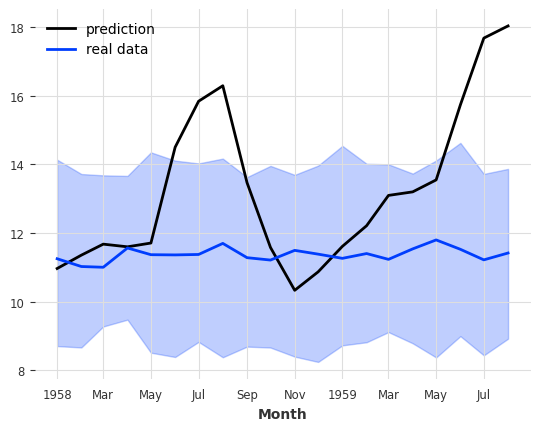

In [10]:
prediction = rnn_model.predict(20,num_samples=100)
prediction = scaler.inverse_transform(prediction)
validation_plot = scaler.inverse_transform(airpass_validation_scaled)
validation_plot.slice_intersect(prediction).plot(label="prediction")
prediction.plot(label="real data")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


c:\Users\KETABI\anaconda3\envs\ml-tools\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |          | 0/? [00:00<?, ?it/s]

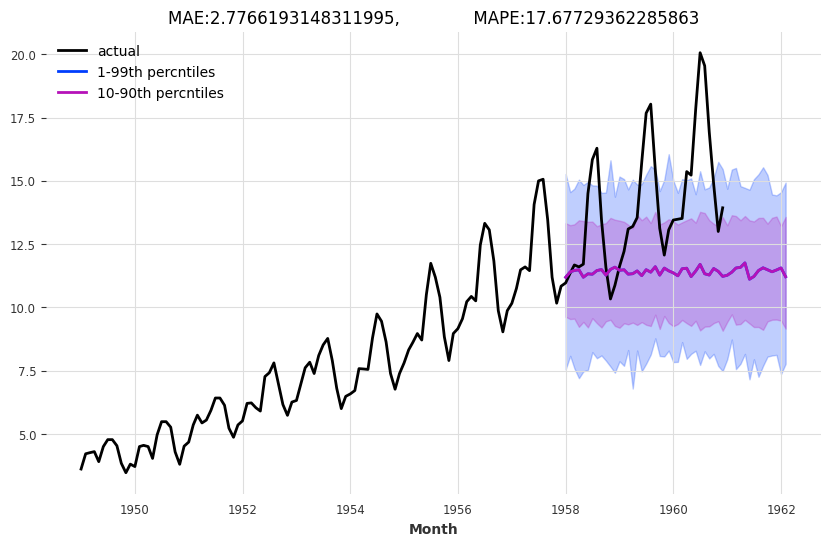

In [11]:
model_evaluation(rnn_model,50,airpass_scaled,airpass_validation_scaled)

In [12]:
nbeats_model = NBEATSModel(
    input_chunk_length=20
    ,
    output_chunk_length=10
    ,
    num_layers = 5
    ,
    num_stacks=5
    ,
    num_blocks=2
    ,
    dropout=0.2
    ,
    n_epochs=50
)

In [13]:
nbeats_model.fit(airpass_train_scaled)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 2.7 M  | train
-------------------------------------------------------------
2.7 M     Trainable params
1.4 K     Non-trainable params
2.7 M     Total params
10.852    Total estimated model params size (MB)
176       Modules in train mode
0         Modules in eval mode
c:\Users\KETABI\anaconda3\envs\ml-tools\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then d

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=5, num_blocks=2, num_layers=5, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.2, activation=ReLU, input_chunk_length=20, output_chunk_length=10, n_epochs=50)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

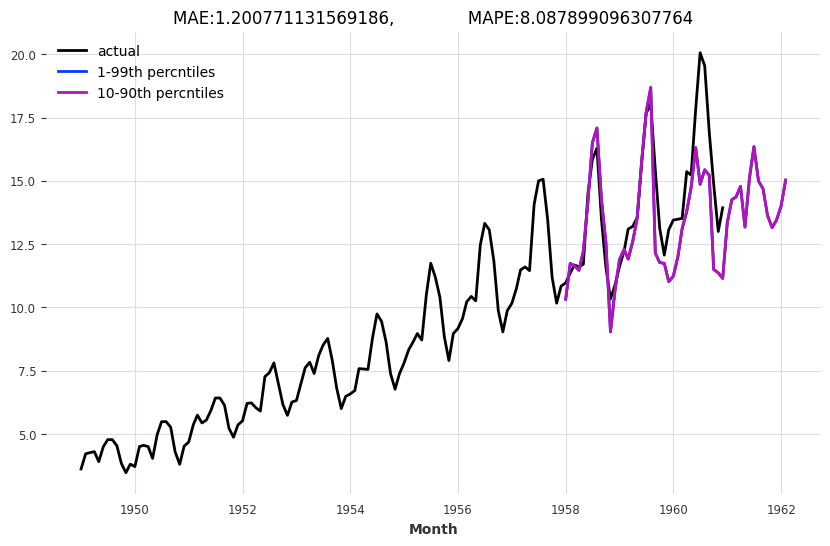

In [14]:
model_evaluation(nbeats_model,50,airpass_scaled,airpass_validation_scaled)

In [15]:
tft_model = TFTModel(
    input_chunk_length=50
    ,
    output_chunk_length=20
    ,
    lstm_layers=10
    ,
    num_attention_heads=10
    ,
    hidden_size=20
    ,
    n_epochs=100
)

In [16]:
tft_model.fit(airpass_train_scaled,future_covariates=cov_scaled)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 2.8 K  | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 2.0 K  | train
6  | static_context_grn                | _GatedResidualNetwork            | 1.7 K  | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


TFTModel(output_chunk_shift=0, hidden_size=20, lstm_layers=10, num_attention_heads=10, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=50, output_chunk_length=20, n_epochs=100)

In [17]:
def model_evaluation_with_covariance(model, n, actual_data, val_data,cov):
  num_samples = 200
  quantile01 , quantile02, quantile03, quantile04 = 0.01, 0.1, 0.9, 0.99
  predicted_data = model.predict(n=n, num_samples=num_samples,future_covariates=cov)
  predicted_data = scaler.inverse_transform(predicted_data)
  actual_data = scaler.inverse_transform(actual_data)
  val_data = scaler.inverse_transform(val_data)
  plot.figure(figsize=(10, 6))
  actual_data[:predicted_data.end_time()].plot(label="actual")

  predicted_data.plot(
      low_quantile=quantile01,
      high_quantile=quantile04,
      label=f"{int(quantile01*100)}-{int(quantile04*100)}th percntiles"
  )
  predicted_data.plot(
      low_quantile=quantile02, high_quantile=quantile03,
      label=f"{int(quantile02*100)}-{int(quantile03*100)}th percntiles"
  )
  plot.title(f"MAE:{mae(val_data, predicted_data)},\
              MAPE:{mape(val_data, predicted_data)}")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

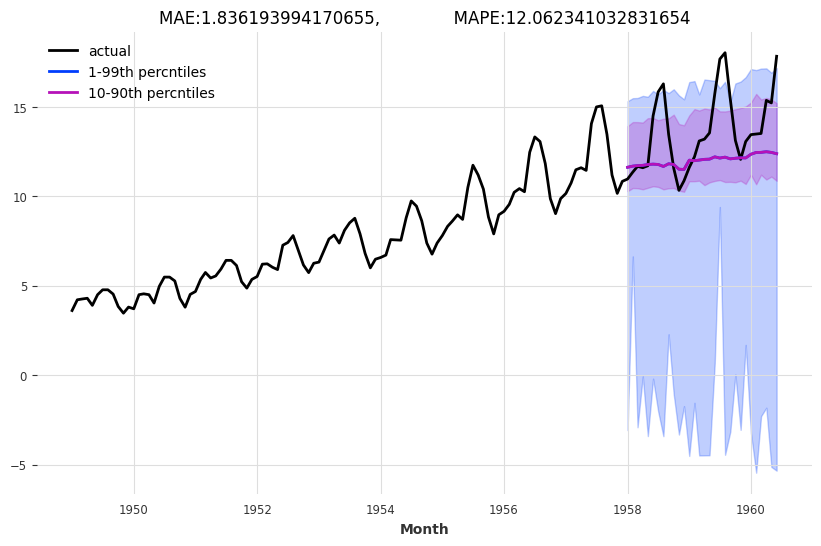

In [18]:
model_evaluation_with_covariance(tft_model,30,airpass_scaled,airpass_validation_scaled,cov_scaled)

In [19]:
tcn_model = TCNModel(
    input_chunk_length=50
    ,
    output_chunk_length=20
    ,
    kernel_size=3
    ,
    num_filters=10
    ,
    num_layers=5
    ,
    dilation_base=2
    ,
    n_epochs=100
    ,
    likelihood = GaussianLikelihood()
)

In [20]:
tcn_model.fit(airpass_train_scaled)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 2.6 K  | train
-------------------------------------------------------------
2.6 K     Trainable params
0         Non-trainable params
2.6 K     Total params
0.010     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode
c:\Users\KETABI\anaconda3\envs\ml-tools\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then d

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


TCNModel(output_chunk_shift=0, kernel_size=3, num_filters=10, num_layers=5, dilation_base=2, weight_norm=False, dropout=0.2, input_chunk_length=50, output_chunk_length=20, n_epochs=100, likelihood=GaussianLikelihood(prior_mu=None, prior_sigma=None, beta_nll=0.0, prior_strength=1.0))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

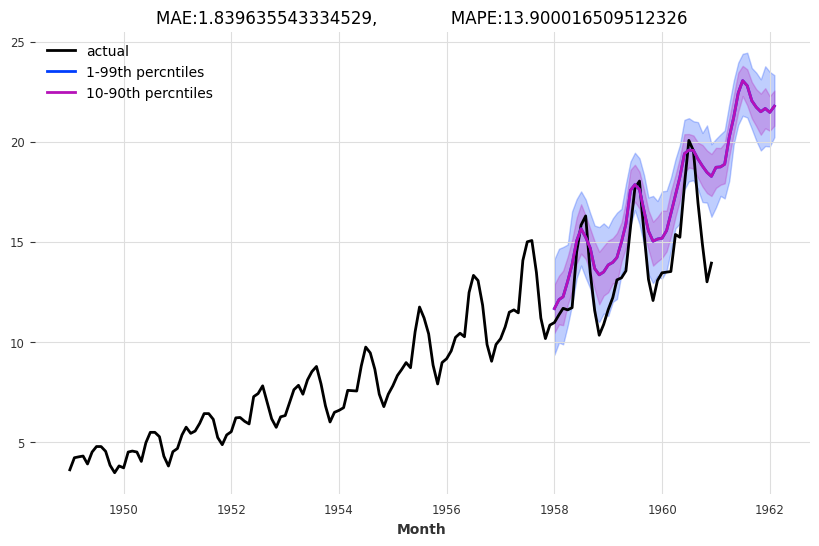

In [21]:
model_evaluation(tcn_model,50,airpass_scaled,airpass_validation_scaled)

In [22]:
print(airpass_train_scaled)

<TimeSeries (DataArray) (Month: 108, component: 1, sample: 1)> Size: 864B
array([[[0.01260894]],

       [[0.06446187]],

       [[0.0682366 ]],

       [[0.0718524 ]],

       [[0.03764139]],

       [[0.08909698]],

       [[0.11273874]],

       [[0.11273874]],

       [[0.09197107]],

       [[0.03207862]],

...

       [[0.69126646]],

       [[0.70127944]],

       [[0.68848507]],

       [[0.91396254]],

       [[0.99443723]],

       [[1.        ]],

       [[0.86222882]],

       [[0.66623401]],

       [[0.57769331]],

       [[0.63563879]]])
Coordinates:
  * Month      (Month) datetime64[ns] 864B 1949-01-01 1949-02-01 ... 1957-12-01
  * component  (component) object 8B '#Passengers'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None


In [23]:
airpass_train_pd = airpass_train_scaled.to_dataframe()
airpass_validation_pd = airpass_validation_scaled.to_dataframe()
airpass_pd = airpass_scaled.to_dataframe()
print(airpass_pd)

            #Passengers
Month                  
1949-01-01     0.012609
1949-02-01     0.064462
1949-03-01     0.068237
1949-04-01     0.071852
1949-05-01     0.037641
...                 ...
1960-08-01     1.386612
1960-09-01     1.161135
1960-10-01     0.983312
1960-11-01     0.821991
1960-12-01     0.902652

[144 rows x 1 columns]


In [25]:
print(airpass_pd.index.min())
print(airpass_pd.index.max())

1949-01-01 00:00:00
1960-12-01 00:00:00


In [26]:
print(airpass_pd)

            #Passengers
Month                  
1949-01-01     0.012609
1949-02-01     0.064462
1949-03-01     0.068237
1949-04-01     0.071852
1949-05-01     0.037641
...                 ...
1960-08-01     1.386612
1960-09-01     1.161135
1960-10-01     0.983312
1960-11-01     0.821991
1960-12-01     0.902652

[144 rows x 1 columns]


In [29]:
def ts_data(airpass_pd,x_steps,y_steps) : 
    train_df = airpass_pd[:"1957"].values.reshape(-1,1)
    test_df = airpass_pd["1957":].values.reshape(-1,1)
    train_x = []
    train_y = []
    for i in range(x_steps,len(train_df)-y_steps+1) : 
        train_x.append(train_df[i-x_steps:i, 0])
        train_y.append(train_df[i:i+y_steps, 0])
    train_x = np.array(train_x)
    train_y = np.array(train_y)
    train_x = np.reshape(train_x,(train_x.shape[0],train_x.shape[1]))

    x = airpass_pd["#Passengers"].values
    x = x[len(x)-len(test_df)-x_steps:]
    x = x.reshape(-1,1)

    test_x = []
    test_y = []
    for j in range(x_steps,len(test_df)+x_steps-y_steps+1) : 
        test_x.append(x[i-x_steps:i, 0])
        test_y.append(x[i:i+y_steps, 0])
    test_x = np.array(test_x)
    test_x = np.reshape(test_x,(test_x.shape[0],test_x.shape[1],1))
    test_y = np.array(test_y)
    return train_x,test_x,train_y,test_y

In [31]:
train_x, test_x, train_y, test_y = ts_data(airpass_pd, 6, 2)